# Assignment 3: Transformer is All You Need
## Tiny Transformer for Next-Token Prediction on Shakespeare

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Data Preparation
### Load data and train a BPE tokenizer (vocab ≤ 500)

In [18]:
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"First 200 chars:\n{text[:200]}")

Total characters: 1,115,394
First 200 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [19]:
tokenizer = Tokenizer(BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
tokenizer.decoder = ByteLevelDecoder()

trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["<pad>", "<unk>"],
    min_frequency=2,
)

tokenizer.train(files=["input.txt"], trainer=trainer)

VOCAB_SIZE = tokenizer.get_vocab_size()
PAD_ID = tokenizer.token_to_id("<pad>")
print(f"Vocabulary size: {VOCAB_SIZE}")

sample = "First Citizen:\nBefore we proceed"
encoded = tokenizer.encode(sample)
print(f"\nSample encoding: '{sample}'")
print(f"Token IDs: {encoded.ids}")
print(f"Tokens:    {encoded.tokens}")
print(f"Decoded:   {tokenizer.decode(encoded.ids)}")




Vocabulary size: 500

Sample encoding: 'First Citizen:
Before we proceed'
Token IDs: [482, 231, 85, 47, 64, 90, 10, 65, 14, 43, 359, 142, 395, 119, 126]
Tokens:    ['First', 'ĠC', 'it', 'i', 'z', 'en', ':', 'Ċ', 'B', 'e', 'fore', 'Ġwe', 'Ġpro', 'ce', 'ed']
Decoded:   First Citizen:
Before we proceed


### Tokenize entire corpus and create overlapping sequences

In [20]:
SEQ_LEN = 50  # context window length
STRIDE = 25   # overlap by half for overlapping sequences

encoded_full = tokenizer.encode(text)
all_token_ids = encoded_full.ids
print(f"Total tokens in corpus: {len(all_token_ids):,}")

sequences = []
for i in range(0, len(all_token_ids) - SEQ_LEN, STRIDE):
    seq = all_token_ids[i : i + SEQ_LEN + 1]  # +1 so we can split into input/target
    if len(seq) == SEQ_LEN + 1:
        sequences.append(seq)

sequences = torch.tensor(sequences, dtype=torch.long)
inputs = sequences[:, :-1]   # first N tokens
targets = sequences[:, 1:]   # shifted by one

print(f"Number of sequences: {len(sequences):,}")
print(f"Input shape:  {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"\nExample input:  {inputs[0][:10].tolist()}")
print(f"Example target: {targets[0][:10].tolist()}")

Total tokens in corpus: 516,697
Number of sequences: 20,666
Input shape:  torch.Size([20666, 50])
Target shape: torch.Size([20666, 50])

Example input:  [482, 231, 85, 47, 64, 90, 10, 65, 14, 43]
Example target: [231, 85, 47, 64, 90, 10, 65, 14, 43, 359]


### Train/Validation split (80/20) and DataLoaders

In [21]:
class ShakespeareDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

split = int(0.8 * len(inputs))
train_dataset = ShakespeareDataset(inputs[:split], targets[:split])
val_dataset = ShakespeareDataset(inputs[split:], targets[split:])

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")
print(f"Train batches:   {len(train_loader)}")
print(f"Val batches:     {len(val_loader)}")

Train sequences: 16,532
Val sequences:   4,134
Train batches:   259
Val batches:     65


## 2. Tiny Transformer Implementation
### RMSNorm, Positional Encoding, Self-Attention, Feed-Forward, and full model

In [22]:
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization."""
    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

In [23]:
class SinusoidalPositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding from 'Attention Is All You Need'."""
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

In [24]:
class CausalSelfAttention(nn.Module):
    """Multi-head self-attention with a causal mask."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        self._attn_weights = None  # stored for visualization

    def forward(self, x):
        B, T, C = x.shape
        q = self.W_q(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        # q, k, v: (B, n_heads, T, head_dim)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        causal_mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        self._attn_weights = attn_weights.detach()  # save for visualization
        attn_weights = self.dropout(attn_weights)

        out = attn_weights @ v  # (B, n_heads, T, head_dim)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)

In [25]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation."""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [26]:
class TransformerBlock(nn.Module):
    """Single Transformer decoder block with pre-norm (RMSNorm) and residual connections."""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # residual around attention
        x = x + self.ff(self.norm2(x))     # residual around feed-forward
        return x


class TinyTransformer(nn.Module):
    """Tiny Transformer language model for next-token prediction."""
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.norm_f = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

        self.lm_head.weight = self.token_emb.weight  # weight tying

    def forward(self, x):
        # x: (B, T) token ids
        tok_emb = self.token_emb(x)          # (B, T, d_model)
        x = self.pos_enc(tok_emb)
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm_f(x)                   # (B, T, d_model)
        logits = self.lm_head(x)             # (B, T, vocab_size)
        return logits

In [27]:
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 2
D_FF = 4 * D_MODEL  # 512
DROPOUT = 0.1
MAX_LEN = SEQ_LEN

model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    max_len=MAX_LEN,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(model)

Total parameters:     460,660
Trainable parameters: 460,660
TinyTransformer(
  (token_emb): Embedding(500, 128)
  (pos_enc): SinusoidalPositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (norm1): RMSNorm()
      (attn): CausalSelfAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): RMSNorm()
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.1, inplace=False)
       

## 3. Training
### Train with cross-entropy loss for next-token prediction

In [28]:
EPOCHS = 20
LR = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        logits = model(batch_inputs)  # (B, T, V)
        loss = criterion(logits.view(-1, VOCAB_SIZE), batch_targets.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch_inputs, batch_targets in val_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            logits = model(batch_inputs)
            loss = criterion(logits.view(-1, VOCAB_SIZE), batch_targets.view(-1))
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step()

    ppl = math.exp(avg_val_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {ppl:.2f}")

Epoch  1/20 | Train Loss: 14.5868 | Val Loss: 6.1132 | Val PPL: 451.80
Epoch  2/20 | Train Loss: 5.6360 | Val Loss: 5.3478 | Val PPL: 210.16
Epoch  3/20 | Train Loss: 5.2602 | Val Loss: 5.1458 | Val PPL: 171.71
Epoch  4/20 | Train Loss: 5.0977 | Val Loss: 4.9826 | Val PPL: 145.86
Epoch  5/20 | Train Loss: 4.8854 | Val Loss: 4.7887 | Val PPL: 120.14
Epoch  6/20 | Train Loss: 4.6483 | Val Loss: 4.6127 | Val PPL: 100.75
Epoch  7/20 | Train Loss: 4.4726 | Val Loss: 4.4650 | Val PPL: 86.92
Epoch  8/20 | Train Loss: 4.3444 | Val Loss: 4.3802 | Val PPL: 79.85
Epoch  9/20 | Train Loss: 4.2524 | Val Loss: 4.3163 | Val PPL: 74.91
Epoch 10/20 | Train Loss: 4.1840 | Val Loss: 4.2712 | Val PPL: 71.61
Epoch 11/20 | Train Loss: 4.1317 | Val Loss: 4.2264 | Val PPL: 68.47
Epoch 12/20 | Train Loss: 4.0914 | Val Loss: 4.2058 | Val PPL: 67.08
Epoch 13/20 | Train Loss: 4.0605 | Val Loss: 4.1822 | Val PPL: 65.51
Epoch 14/20 | Train Loss: 4.0368 | Val Loss: 4.1681 | Val PPL: 64.59
Epoch 15/20 | Train Loss: 4

## 4. Visualization & Interpretation
### Training and Validation Loss Curves

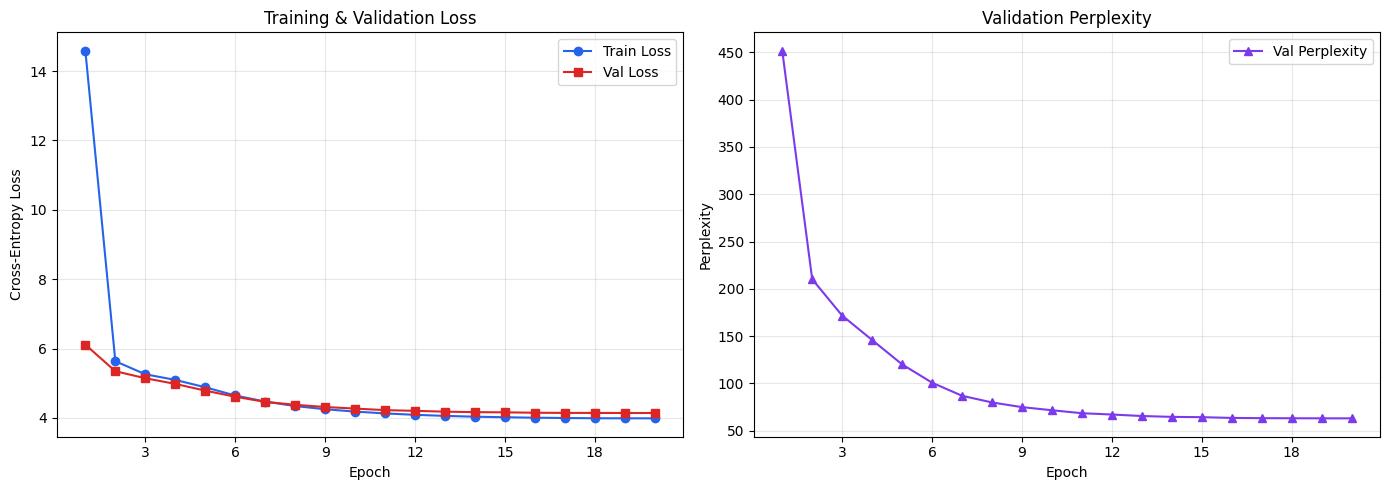


Final Val Loss: 4.1439
Final Val Perplexity: 63.05


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, "o-", label="Train Loss", color="#2563eb")
ax1.plot(epochs_range, val_losses, "s-", label="Val Loss", color="#dc2626")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

val_ppls = [math.exp(l) for l in val_losses]
ax2.plot(epochs_range, val_ppls, "^-", label="Val Perplexity", color="#7c3aed")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Perplexity")
ax2.set_title("Validation Perplexity")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFinal Val Loss: {val_losses[-1]:.4f}")
print(f"Final Val Perplexity: {val_ppls[-1]:.2f}")

### Validation Perplexity (final, computed over entire val set)

In [30]:
model.eval()
total_loss = 0.0
total_tokens = 0

with torch.no_grad():
    for batch_inputs, batch_targets in val_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)

        logits = model(batch_inputs)
        loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), batch_targets.view(-1), reduction="sum")
        total_loss += loss.item()
        total_tokens += batch_targets.numel()

avg_ce = total_loss / total_tokens
perplexity = math.exp(avg_ce)
print(f"Validation Cross-Entropy Loss (per token): {avg_ce:.4f}")
print(f"Validation Perplexity (PPL):                {perplexity:.2f}")

Validation Cross-Entropy Loss (per token): 4.1440
Validation Perplexity (PPL):                63.05


### Attention Heatmap Visualization

Sample: 'ROMEO:
O, she doth teach the torches to burn bright!'
Tokens: ['RO', 'M', 'E', 'O', ':', 'Ċ', 'O', ',', 'Ġshe', 'Ġd', 'oth', 'Ġt', 'ea', 'ch', 'Ġthe', 'Ġt', 'or', 'c', 'he', 's', 'Ġto', 'Ġb', 'ur', 'n', 'Ġb']


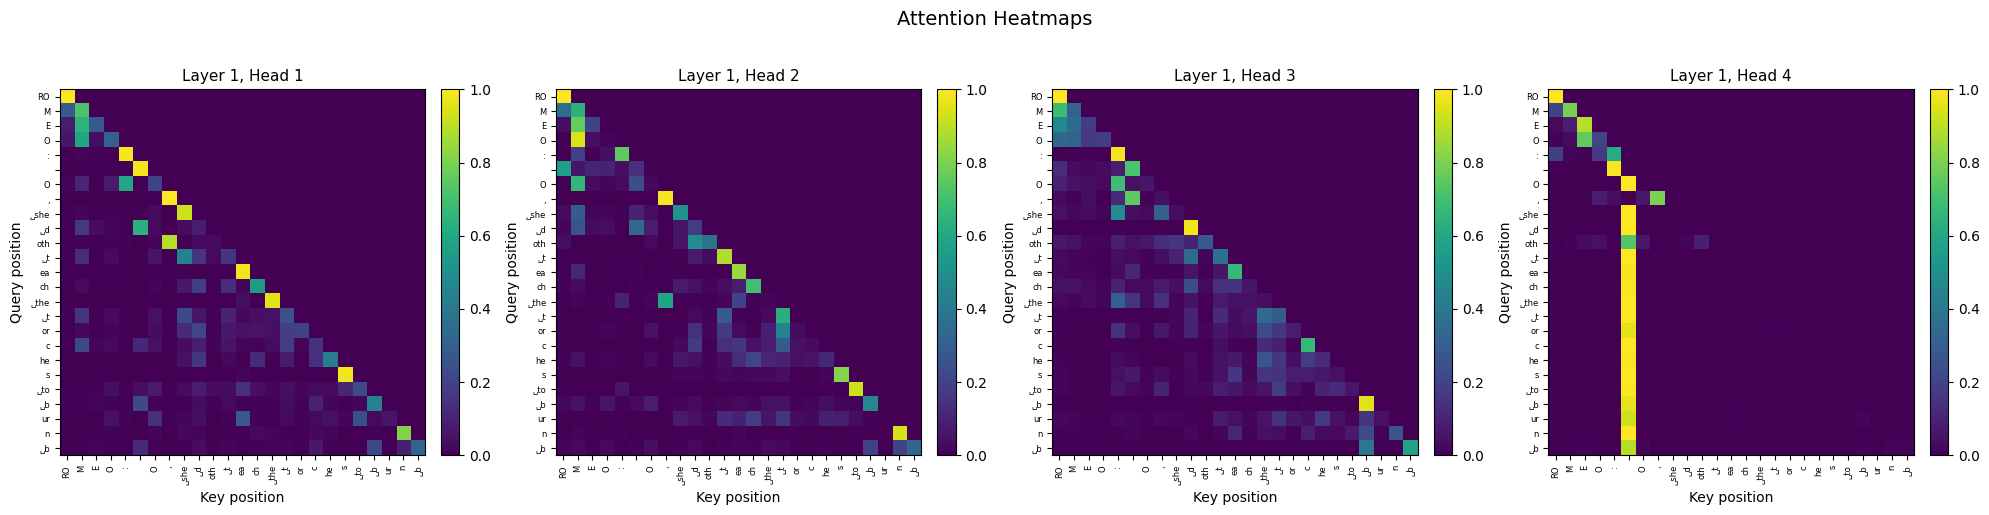

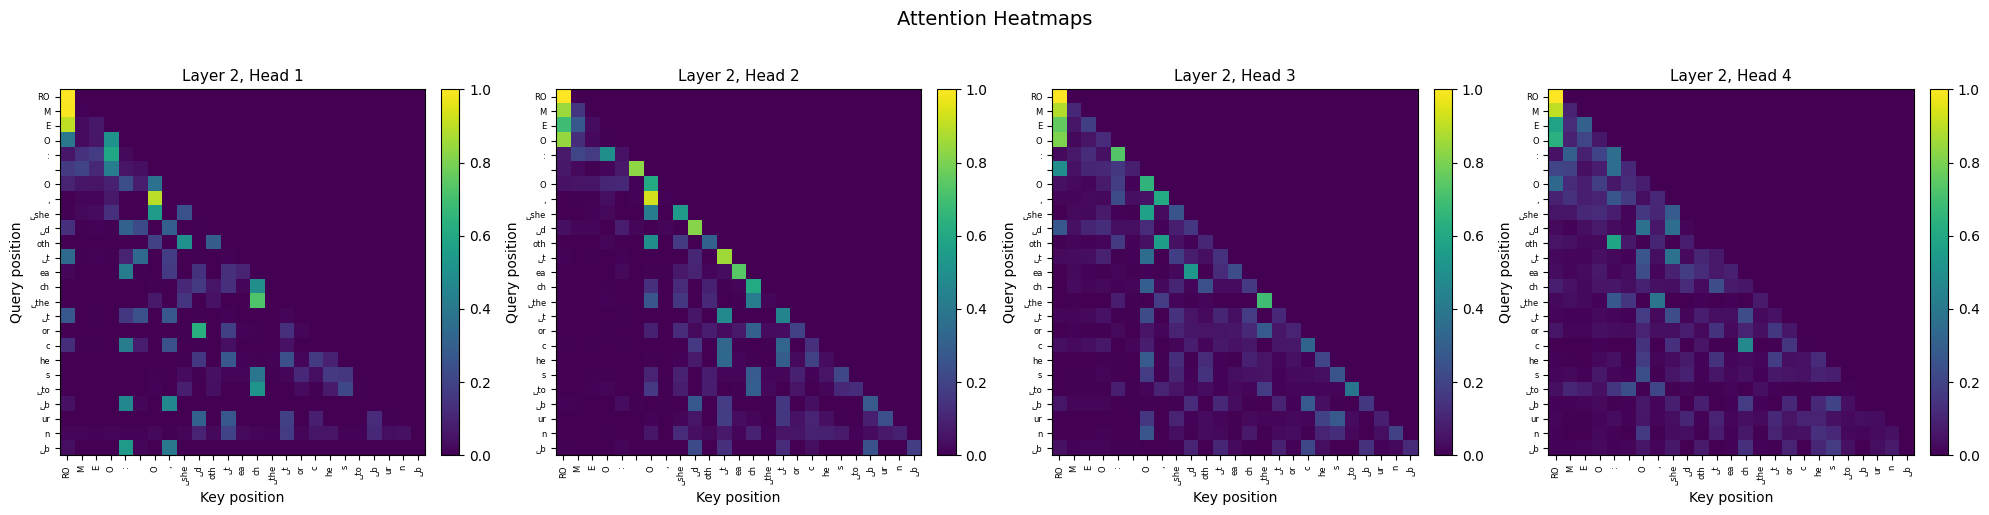

In [31]:
def plot_attention_heatmaps(model, sample_ids, tokenizer, layer_idx=0, max_tokens=25):
    """Visualize attention weights for each head on a sample sequence."""
    model.eval()
    sample_tensor = torch.tensor(sample_ids[:max_tokens], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(sample_tensor)

    attn_block = model.blocks[layer_idx].attn
    attn_weights = attn_block._attn_weights[0]  # (n_heads, T, T)

    n_heads = attn_weights.shape[0]
    T = attn_weights.shape[1]

    tokens_decoded = []
    for tid in sample_ids[:max_tokens]:
        tok = tokenizer.decode([tid]).replace(" ", "\u2423")
        if len(tok) > 8:
            tok = tok[:7] + "…"
        tokens_decoded.append(tok)

    fig, axes = plt.subplots(1, n_heads, figsize=(5 * n_heads, 5))
    if n_heads == 1:
        axes = [axes]

    for h in range(n_heads):
        ax = axes[h]
        w = attn_weights[h].cpu().numpy()
        im = ax.imshow(w, cmap="viridis", aspect="auto", vmin=0)
        ax.set_title(f"Layer {layer_idx + 1}, Head {h + 1}", fontsize=11)
        ax.set_xlabel("Key position")
        ax.set_ylabel("Query position")
        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(tokens_decoded, rotation=90, fontsize=6)
        ax.set_yticklabels(tokens_decoded, fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle("Attention Heatmaps", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"attention_heatmap_layer{layer_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()


sample_text = "ROMEO:\nO, she doth teach the torches to burn bright!"
sample_enc = tokenizer.encode(sample_text)
print(f"Sample: '{sample_text}'")
print(f"Tokens: {sample_enc.tokens[:25]}")

for layer in range(N_LAYERS):
    plot_attention_heatmaps(model, sample_enc.ids, tokenizer, layer_idx=layer, max_tokens=25)

### Text Generation (qualitative evaluation)

In [32]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=200, temperature=0.8, top_k=40):
    """Auto-regressive text generation with top-k sampling."""
    model.eval()
    encoded = tokenizer.encode(prompt)
    token_ids = encoded.ids

    for _ in range(max_new_tokens):
        context = token_ids[-SEQ_LEN:]  # crop to context window
        x = torch.tensor([context], dtype=torch.long, device=device)
        logits = model(x)
        logits = logits[0, -1, :] / temperature  # last position

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[-1]] = float("-inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        token_ids.append(next_id)

    return tokenizer.decode(token_ids)


prompts = [
    "ROMEO:\n",
    "To be, or not to be",
    "KING HENRY:\nMy lords,",
    "First Citizen:\n",
]

for prompt in prompts:
    generated = generate(model, tokenizer, prompt, max_new_tokens=150, temperature=0.8, top_k=40)
    print(f"{'='*60}")
    print(f"PROMPT: {repr(prompt)}")
    print(f"{'='*60}")
    print(generated)
    print()

PROMPT: 'ROMEO:\n'
ROMEO:
This my word, and hough?


And a hast thou Thyalds and pow being;
It, I'll a land; but but to a, my lord,
As if you most guck besiuss, the world is that you.



MENENENIUS:
If he delland; bros, in the take you's done,
And to do the child of a tay, and scatorrown of thy leace,
And bretheby in your sle that exaintas,
And

PROMPT: 'To be, or not to be'
To be, or not to beings;
For thou, that pertwieer'd for it
Saile, thou life, that, myself, witle,
And being put; and the moudopind bered.

Theret to fock.
GLOUCESTER:
Would I would the wors to the lend. Herefecter.
You otccurnotded that thou art thou artent.


PPUTES:
So:
Stizours, as
O, I but but I am he in ter, in h

PROMPT: 'KING HENRY:\nMy lords,'
KING HENRY:
My lords, so pey leave the reven, that waneds the
That, he purn'd sit, to my laught, welose to the pes of the world
Wheren.  What word of Clish.


ANNORIOLANUS:
You but before I to the couces; pie of thine.


ROMEO:
Come, way, wite, whore, and thou do Joee

## 5. Summary

### Hyperparameters
| Parameter | Value |
|---|---|
| Vocab Size | ≤ 500 (BPE) |
| Sequence Length | 50 tokens |
| d_model | 128 |
| Heads | 4 |
| Layers | 2 |
| d_ff | 512 |
| Dropout | 0.1 |
| Optimizer | AdamW (lr=3e-4, wd=0.01) |
| Scheduler | Cosine Annealing |
| Epochs | 20 |
| Batch Size | 64 |

### Architecture highlights
- **Subword tokenization**: Byte Pair Encoding for meaningful sub-word units
- **Sinusoidal positional encoding**: Fixed, non-learned position information
- **Causal self-attention**: Prevents attending to future tokens
- **Pre-norm architecture**: RMSNorm applied before attention and FFN (more stable training)
- **Residual connections**: Around both self-attention and feed-forward blocks
- **Weight tying**: Embedding and output projection share weights (reduces parameters)